# Fine-Tuned Model — MobileNetV2 (No Augmentation)

## Purpose

This notebook fine-tunes a pretrained MobileNetV2 model on the campus dataset **without data augmentation**. Rather than retraining Phase 1 from scratch, it loads the already-trained baseline model (`baseline_mobilenetv2_best.keras`) as the starting point for fine-tuning.

This means Phase 2 begins from the strongest possible frozen baseline (94.02% test accuracy) and directly measures how much fine-tuning alone adds on top.

The preprocessing pipeline is imported directly from `src/preprocessing.py`.

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries and dataset loading via `src.preprocessing` |
| 2. Load Data | Call `get_datasets()` and verify split sizes |
| 3. Build or Load Model | Load baseline model if it exists, otherwise train Phase 1 from scratch |
| 4. Phase 2 — Fine-Tuning | Unfreeze top 30 layers, retrain at lower learning rate |
| 5. Evaluate | Compare best and last saved models on the test set |
| 6. Training Curves | Accuracy and loss plots for Phase 2 |
| 7. Misclassified Images | Visualise images the model got wrong |

---

## Strategy

Instead of a two-phase training loop, this notebook:

1. **Loads** the frozen baseline (`baseline_mobilenetv2_best.keras`) which was already trained in `02_baseline_model_MobileNetV2.ipynb`
2. **Unfreezes** the top 30 MobileNetV2 layers
3. **Retrains** at `1e-5` learning rate to gently adapt the base features to campus buildings

If the baseline model file does not exist, the notebook falls back to training Phase 1 from scratch automatically.

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.insert(0, str(Path().resolve().parent))

from src.preprocessing import (
    get_datasets,
    IMAGE_SIZE,
    BATCH_SIZE,
    RANDOM_SEED,
)

MODELS_DIR = Path().resolve().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Image size:        ", IMAGE_SIZE)
print("Batch size:        ", BATCH_SIZE)
print("Random seed:       ", RANDOM_SEED)

TensorFlow version: 2.16.2
Image size:         (224, 224)
Batch size:         32
Random seed:        42


## 2. Load Data

In [2]:
train_ds, val_ds, test_ds, class_names = get_datasets()

NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}):       {class_names}")
print(f"Train batches:      {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches:       {len(test_ds)}")

Classes (8):       ['2', '3', '4', '5', '7', '8', '9', '10']
Train batches:      27
Validation batches: 6
Test batches:       6


2026-04-13 15:11:54.737556: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-13 15:11:54.737579: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-13 15:11:54.737583: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-13 15:11:54.737598: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-13 15:11:54.737609: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 3. Build or Load Model

This step checks whether the trained baseline model (`baseline_mobilenetv2_best.keras`) already exists on disk.

- **If it exists** — the model is loaded directly. This avoids retraining Phase 1 and starts fine-tuning from the strongest possible weights (94.02% test accuracy from notebook `02`).
- **If it does not exist** — the model is built from scratch and Phase 1 (head training with frozen base) is run first. This is a fallback to ensure the notebook is self-contained.

Either way, the result is a trained model ready for Phase 2 fine-tuning.

In [3]:
BASELINE_PATH = MODELS_DIR / "baseline_mobilenetv2_best.keras"

def load_or_train_phase1():
    """
    Loads the baseline model if it exists, otherwise trains Phase 1 from scratch.

    Returns:
        model      : trained Keras model ready for Phase 2 fine-tuning
        history_p1 : training history if Phase 1 was trained, else None
    """
    if BASELINE_PATH.exists():
        print(f"Baseline model found — loading from {BASELINE_PATH.name}")
        model = tf.keras.models.load_model(BASELINE_PATH)
        print("Model loaded successfully. Skipping Phase 1 training.")
        return model, None

    print("Baseline model not found — building and training Phase 1 from scratch.")

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print("Phase 1 — training classification head (base frozen)")
    history_p1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=[early_stopping]
    )

    return model, history_p1


model, history_p1 = load_or_train_phase1()
model.summary()

Baseline model found — loading from baseline_mobilenetv2_best.keras
Model loaded successfully. Skipping Phase 1 training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,288,730 (8.73 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 20,498 (80.07 KB)

## 4. Phase 2 — Fine-Tuning

The top 30 layers of the MobileNetV2 base are unfrozen and retrained alongside the classification head.

### Why 30 layers?

MobileNetV2 has 155 layers. The top 30 contain the highest-level feature detectors — most likely to benefit from adapting to campus buildings. The earlier layers detect universal low-level features like edges and textures that do not need to change.

### Why `1e-5` learning rate?

The pretrained weights are already good. A very low learning rate gently nudges them towards campus-specific features without overwriting them.

Models are saved to:
- `models/finetuned_mobilenetv2_best.keras` — best checkpoint during Phase 2
- `models/finetuned_mobilenetv2_last.keras` — end of Phase 2

In [4]:
# Access the MobileNetV2 base — first layer of the loaded/built model
base_model = model.layers[0]

# Unfreeze the top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers: {trainable_count} / {len(base_model.layers)}")

# Recompile with a much lower learning rate to avoid overwriting pretrained weights
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

early_stopping_p2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_p2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "finetuned_mobilenetv2_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Phase 2 — fine-tuning top 30 base layers")
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_p2, checkpoint_p2]
)

model.save(MODELS_DIR / "finetuned_mobilenetv2_last.keras")
print("Phase 2 complete.")

Trainable base layers: 30 / 154
Phase 2 — fine-tuning top 30 base layers
Epoch 1/20


2026-04-13 15:11:56.961711: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6231 - loss: 1.0569
Epoch 1: val_loss improved from None to 0.19864, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/finetuned_mobilenetv2_best.keras

Epoch 1: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/finetuned_mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.6394 - loss: 1.0208 - val_accuracy: 0.9348 - val_loss: 0.1986
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7673 - loss: 0.7010
Epoch 2: val_loss did not improve from 0.19864
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8086 - loss: 0.5804 - val_accuracy: 0.9293 - val_loss: 0.2061
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8502 - loss: 0.4312
Epoch 3: val_loss did not improve from 0.19864
27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8728 - loss: 0.3934 - val_accuracy: 0.9185 - val_loss: 0.2173
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/ste

## 5. Evaluate

Both saved Phase 2 models are evaluated on the test set. Compare these results against the baseline MobileNetV2 (94.02%) to measure the improvement from fine-tuning alone.

In [5]:
saved_models = {
    "Best  (lowest val_loss)": MODELS_DIR / "finetuned_mobilenetv2_best.keras",
    "Last  (end of training)": MODELS_DIR / "finetuned_mobilenetv2_last.keras",
}

print(f"{'Model':<30} {'Loss':>8}  {'Accuracy':>10}")
print("-" * 52)

for label, model_path in saved_models.items():
    loaded_model = tf.keras.models.load_model(model_path)
    loss, acc = loaded_model.evaluate(test_ds, verbose=0)
    print(f"{label:<30} {loss:>8.4f}  {acc * 100:>9.2f}%")

Model                              Loss    Accuracy
----------------------------------------------------
Best  (lowest val_loss)          0.2231      94.02%
Last  (end of training)          0.2231      94.02%


## 6. Training Curves

Phase 2 accuracy and loss over epochs. Since we loaded the pretrained baseline, only Phase 2 history is available to plot.

If Phase 1 was trained from scratch (fallback path), both phases are shown.

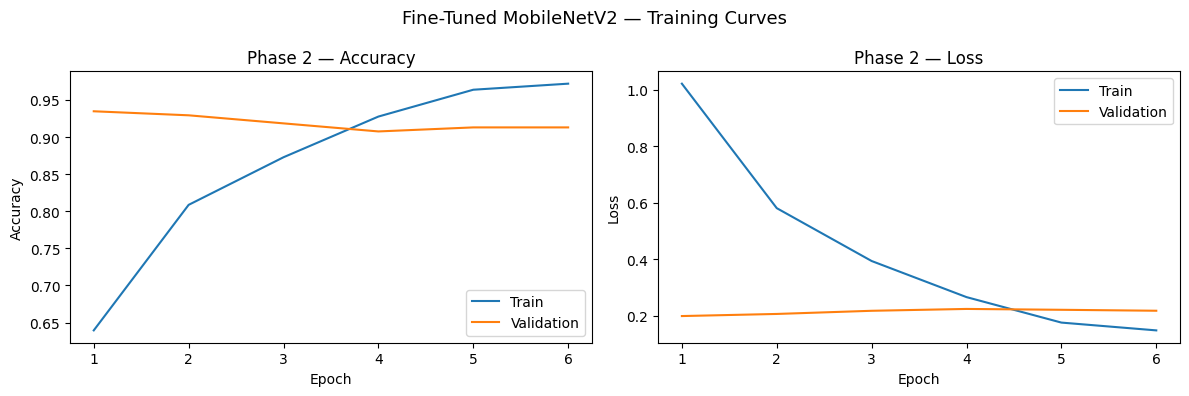

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history_p2.history["accuracy"]) + 1)

axes[0].plot(epochs_range, history_p2.history["accuracy"],     label="Train")
axes[0].plot(epochs_range, history_p2.history["val_accuracy"], label="Validation")
axes[0].set_title("Phase 2 — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, history_p2.history["loss"],     label="Train")
axes[1].plot(epochs_range, history_p2.history["val_loss"], label="Validation")
axes[1].set_title("Phase 2 — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Fine-Tuned MobileNetV2 — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Misclassified Images

Visualising the images the model got wrong helps identify remaining patterns in its mistakes and compare them against the frozen baseline.

Loading model: finetuned_mobilenetv2_best


2026-04-13 15:16:07.902972: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total images:         184
Correctly classified: 173
Misclassified:        11
Accuracy:             94.02%


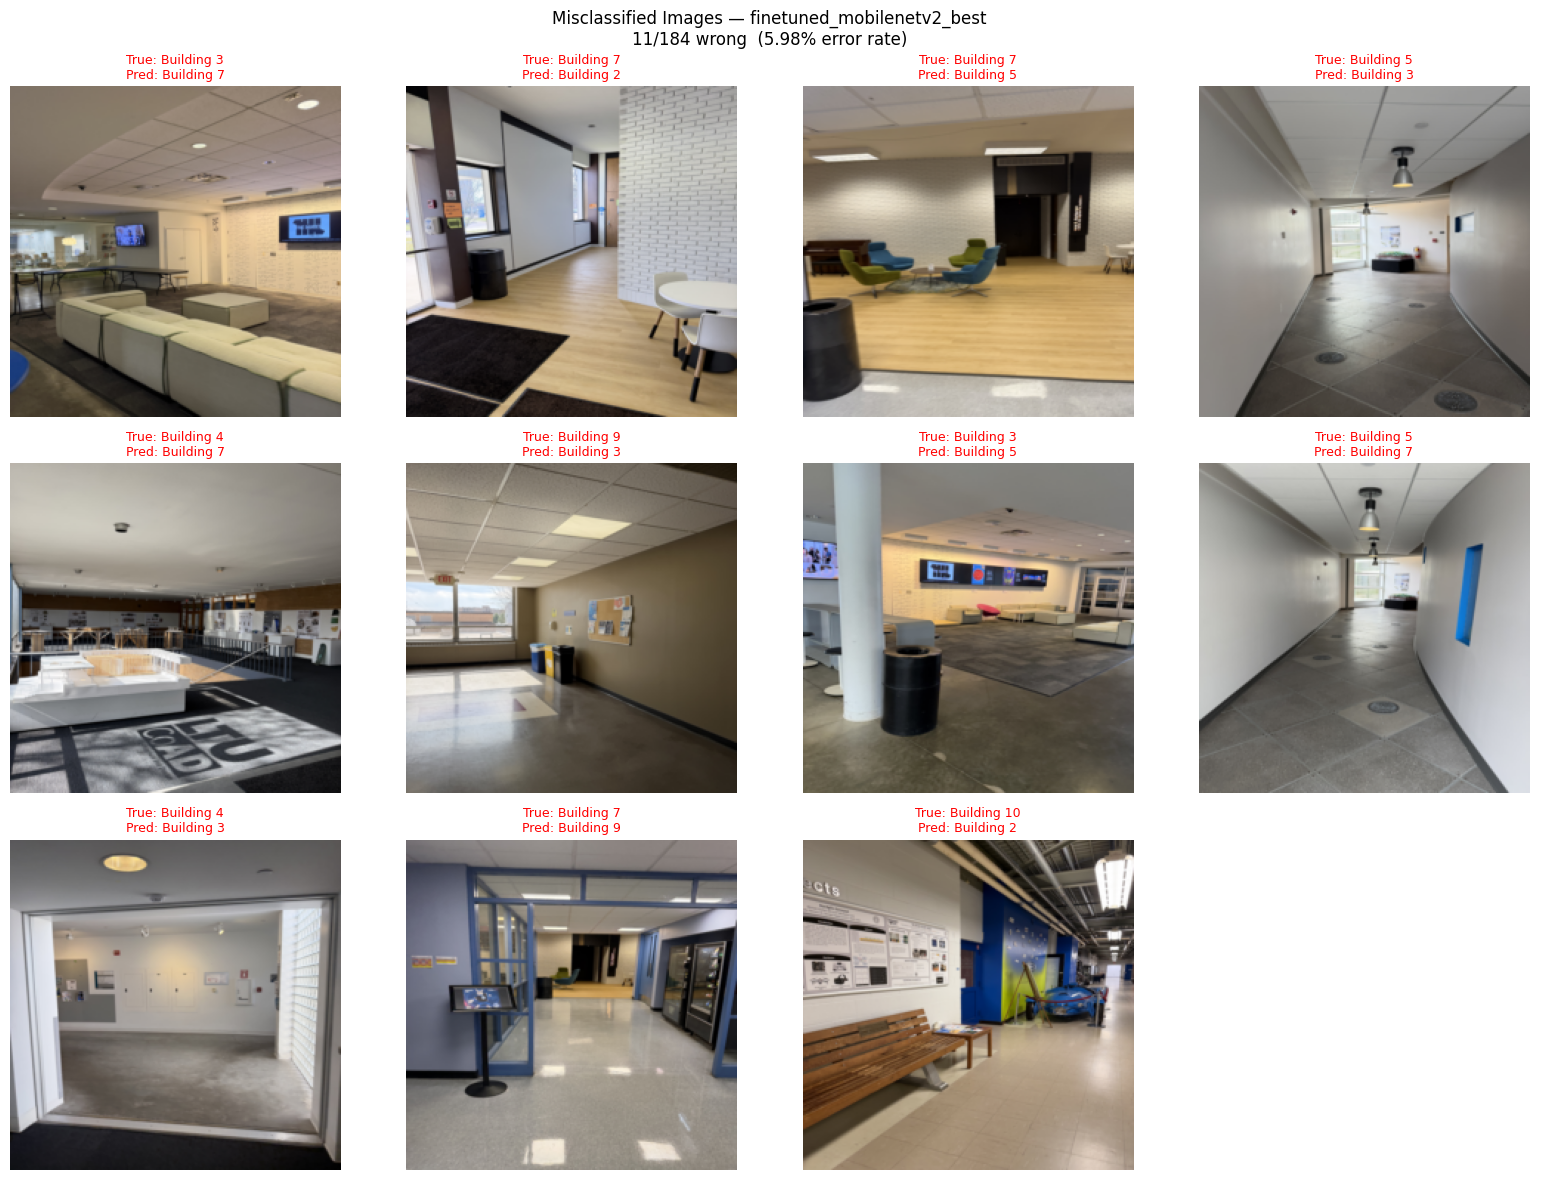

In [7]:
from src.visualize import show_misclassified

show_misclassified("finetuned_mobilenetv2_best", test_ds, class_names)